In [27]:
from typing import Dict, TypedDict, List

import random
from langgraph.graph import StateGraph, START, END

In [28]:
class AgentState(TypedDict):
    name : str
    nums : List[int]
    counter : int 


In [29]:
def greeting_node(state: AgentState):
    state["name"] = "Good Morning Pineapple"
    return state


def random_node(state: AgentState):
    state["nums"].append(random.randint(1, 100))
    state["counter"] += 1
    return state


def should_continue(state: AgentState):
    if state["counter"] >= 5:
        return "end_edge"
    else:
        return "loop_edge"


In [30]:
graph = StateGraph(AgentState)

graph.add_node("greeting_node", greeting_node)
graph.add_node("random_node", random_node)

graph.add_edge(START, "greeting_node")
graph.add_edge("greeting_node", "random_node")

graph.add_conditional_edges(
    "random_node",
    should_continue,
    {
        "loop_edge": "random_node",
        "end_edge": END,
    },
)

app = graph.compile()


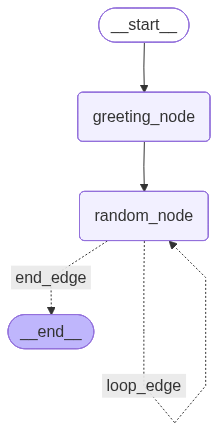

In [31]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [32]:
result = app.invoke(
    {
        "name": "",
        "nums": [],
        "counter": 0,
    }
)

print(result)

{'name': 'Good Morning Pineapple', 'nums': [7, 45, 40, 17, 27], 'counter': 5}
